## The Random Forest

The Random Forest is strongly based on the Decision Tree model but adds more complexity to it. As the name suggests, a Random Forest consists of a large number of Decision Trees, each of them with a slight variation.

READ MORE ON PAGE 180.

### Predicting Sunspots Using a Random Forest

Let’s develop an example of the Random Forest model. For this we’ll again take the sunspot data that we’ve used in the ARMA model. The ARMA model was able to obtain an R2 of 0.84. This time let’s try to forecast the monthly number of sunspots rather than the yearly sum as was done in the ARMA example.

In [11]:
import pandas as pd

data=pd.read_csv('../database/Sunspots.csv', usecols=[1,2])
data

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3260,2020-09-30,0.6
3261,2020-10-31,14.4
3262,2020-11-30,34.0
3263,2020-12-31,21.8


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               3265 non-null   object 
 1   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1), object(1)
memory usage: 51.1+ KB


Now it is necessary to add some feature engineering. Let’s add the variables Year and Month to account for seasonality and the lagged versions of the target variable for the past 12 months. This task can be expected to be a bit harder, as there is a more detailed variation that the model needs to learn. 

In [13]:
## Feature Engineering

# Seasonality variables
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].apply(lambda x: x.year)
data['Month'] = data['Date'].apply(lambda x: x.month)

# Adding a year of lagged data
data['L1'] = data['Monthly Mean Total Sunspot Number'].shift(1)
data['L2'] = data['Monthly Mean Total Sunspot Number'].shift(2)
data['L3'] = data['Monthly Mean Total Sunspot Number'].shift(3)
data['L4'] = data['Monthly Mean Total Sunspot Number'].shift(4)
data['L5'] = data['Monthly Mean Total Sunspot Number'].shift(5)
data['L6'] = data['Monthly Mean Total Sunspot Number'].shift(6)
data['L7'] = data['Monthly Mean Total Sunspot Number'].shift(7)
data['L8'] = data['Monthly Mean Total Sunspot Number'].shift(8)
data['L9'] = data['Monthly Mean Total Sunspot Number'].shift(9)
data['L10'] = data['Monthly Mean Total Sunspot Number'].shift(10)
data['L11'] = data['Monthly Mean Total Sunspot Number'].shift(11)
data['L12'] = data['Monthly Mean Total Sunspot Number'].shift(12)

data=data.dropna()

In [14]:
data

,Date,Monthly Mean Total Sunspot Number,Year,Month,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10,L11,L12
12,1750-01-31,122.2,1750,1,142.0,264.3,125.8,126.5,110.5,158.0,139.2,141.7,92.8,116.7,104.3,96.7
13,1750-02-28,126.5,1750,2,122.2,142.0,264.3,125.8,126.5,110.5,158.0,139.2,141.7,92.8,116.7,104.3
14,1750-03-31,148.7,1750,3,126.5,122.2,142.0,264.3,125.8,126.5,110.5,158.0,139.2,141.7,92.8,116.7
15,1750-04-30,147.2,1750,4,148.7,126.5,122.2,142.0,264.3,125.8,126.5,110.5,158.0,139.2,141.7,92.8
16,1750-05-31,150.0,1750,5,147.2,148.7,126.5,122.2,142.0,264.3,125.8,126.5,110.5,158.0,139.2,141.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3260,2020-09-30,0.6,2020,9,7.5,6.1,5.8,0.2,5.2,1.5,0.2,6.2,1.5,0.5,0.4,1.1
3261,2020-10-31,14.4,2020,10,0.6,7.5,6.1,5.8,0.2,5.2,1.5,0.2,6.2,1.5,0.5,0.4
3262,2020-11-30,34.0,2020,11,14.4,0.6,7.5,6.1,5.8,0.2,5.2,1.5,0.2,6.2,1.5,0.5
3263,2020-12-31,21.8,2020,12,34.0,14.4,0.6,7.5,6.1,5.8,0.2,5.2,1.5,0.2,6.2,1.5


In [15]:
# Fitting the default Random Forest regressor

# Create X and y object
data = data.dropna()
y = data['Monthly Mean Total Sunspot Number']
X = data[['Year', 'Month', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 
'L9', 'L10', 'L11', 'L12']]

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, 
random_state=12345, shuffle=False)

from sklearn.ensemble import RandomForestRegressor
my_rf = RandomForestRegressor()

my_rf.fit(X_train, y_train)
fcst = my_rf.predict(X_test)

from sklearn.metrics import r2_score
print("train_score: ",r2_score(list(y_train), list(my_rf.predict(X_train))))
print("test_score: ", r2_score(list(y_test), list(fcst)))

train_score:  0.9796721385472024
test_score:  0.8722521229287047


This is a brilliant performance. We will still use the GridSearch to get the best optimal performance. We will tune the two main hyperparameters for ensemble technique and variable subset, `n_estimators` and `max_features` respectively.

In [16]:
# Fitting the Random Forest regressor with hyperparameter tuning

from sklearn.model_selection import GridSearchCV

rf_model=RandomForestRegressor()
params={'max_features':[0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
'n_estimators': [10, 50, 100, 250, 500, 750, 1000]}

my_rf = GridSearchCV(estimator=rf_model,param_grid=params,
scoring = 'r2', n_jobs = -1)

my_rf.fit(X_train, y_train)

print("train_score: ",r2_score(list(y_train), list(my_rf.predict(X_train))))
print("test_score: ",r2_score(list(y_test), list(my_rf.predict(X_test))))

print(my_rf.best_params_)

train_score:  0.9807093272182456
test_score:  0.8791300937281872
{'max_features': 0.65, 'n_estimators': 750}


This is a slightly better performance with the optimal hyperparameters as {'max_features': 0.65, 'n_estimators': 750}

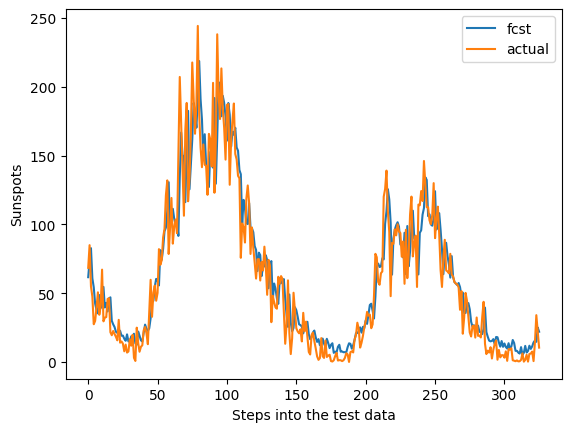

In [17]:
# Obtaining the plot of the forecast on the test data
fcst=my_rf.predict(X_test)

import matplotlib.pyplot as plt

plt.plot(list(fcst))
plt.plot(list(y_test))
plt.legend(['fcst', 'actual'])
plt.ylabel('Sunspots')
plt.xlabel('Steps into the test data')
plt.show()

This is good. Now we will apply RandomSearchCV.

In this application of random search, we’ll use distributions rather than a list of possible values to specify which values we want to test for the different hyperparameters. This is a great functionality of RandomizedSearchCV, especially when 
you have an idea of what the most likely value for your hyperparameters is.

***For the value of max_features in GridSearchCV, we previously tested values between 0.65 and 0.95 with steps of 0.05. The most used distribution is the normal distribution, so let’s see how we could use the normal distribution for this.***

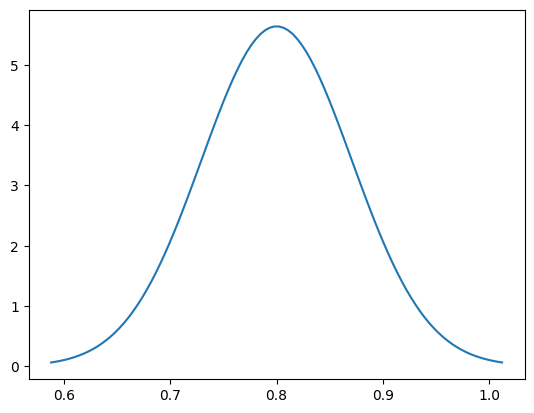

In [18]:
# Testing out a normal distribution for the max_features
import numpy as np
import scipy.stats as stats
import math

mu = 0.8
variance = 0.005
sigma = math.sqrt(variance)

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

As seen in the figure above, the normal distribution with a mean of 0.8 and a standard deviation of 0.05 covers the range of 0.65–1.0 quite well. The x-axis in this graph shows the value for max_features, and the y-axis shows the corresponding probability for this value being sampled into the random search.

You see why RandomSearchCV gives a more deeper search.

***For the distribution of n_estimators, let’s try something different. Let’s say that we want to test values between 50 and 1000 but that we don’t really have a good idea of what the actual value for n_estimators should be. This means that a `uniform distribution` may be appropriate: in a uniform 
distribution, you specify a minimum and a maximum, and all values in between are equally probable to be selected.***

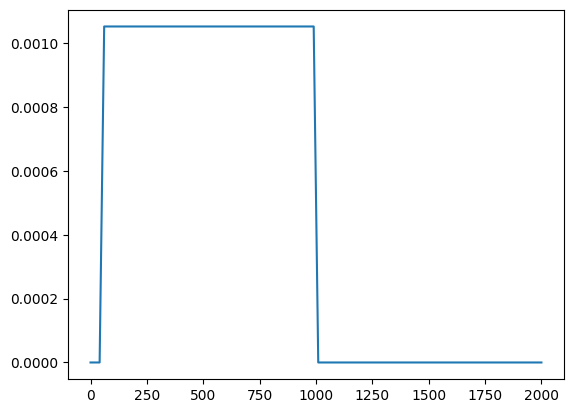

In [19]:
# Testing out a uniform distribution for the n_estimators

x = np.linspace(0, 2000, 100)
plt.plot(x, stats.uniform.pdf(x, 50, 950))
plt.show()

Yet there is a small problem. The uniform distribution returns a floating number, while the n_estimators can only take an integer. The better alternative for a uniform integer is to use the function `scipy.stats.randint`, which returns a random integer between a minimum and a maximum.

In [21]:
# RandomizedSearchCV with two distributions
from sklearn.model_selection import RandomizedSearchCV

rf_model=RandomForestRegressor()
# Specifying the distributions to draw from
distributions = {
'max_features': stats.norm(0.8, math.sqrt(0.005)),
'n_estimators': stats.randint(50, 1000)
}
# Creating the search
my_rf = RandomizedSearchCV(estimator=rf_model,
param_distributions=distributions, n_iter=10,scoring = 'r2',
n_jobs = -1,random_state = 12345)

# Fitting the search
my_rf.fit(X_train, y_train)

# Printing the results
print("train_score: ",r2_score(list(y_train), list(my_rf.predict(X_train))))
print("test_score: ",r2_score(list(y_test), list(my_rf.predict(X_test))))

print(my_rf.best_params_)

train_score:  0.9806700419469568
test_score:  0.8782882503985804
{'max_features': np.float64(0.7024759740118218), 'n_estimators': 819}


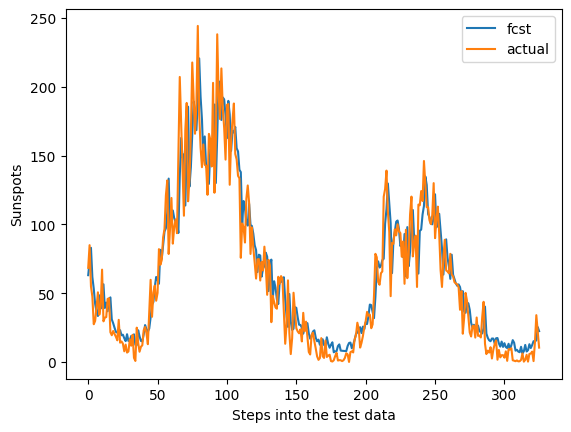

In [23]:
# Obtaining the plot of the forecast on the test data
fcst=my_rf.predict(X_test)

import matplotlib.pyplot as plt

plt.plot(list(fcst))
plt.plot(list(y_test))
plt.legend(['fcst', 'actual'])
plt.ylabel('Sunspots')
plt.xlabel('Steps into the test data')
plt.show()

A good performance. With optimal hyperparameters {'max_features': np.float64(0.7024759740118218), 'n_estimators': 819}

The R2 is slightly lower than the one obtained by the grid search. Yet you should observe a very strong increase in execution time. The ***RandomizedSearchCV is much faster*** while only losing a very slight amount of performance: a great argument for using RandomizedSearchCV rather than GridSearchCV

#### Interpretation

For the Decision Tree model, you have seen how you can plot the tree and follow its decisions based on a new observation. For the Random Forest, you would need to do this many times, making for a very difficult process.

Luckily, an alternative exists for interpreting the Random Forest. This method is called feature importance.

The feature importance of each variable is computed all the way throughout the fitting of the Random Forest. `Every time that a variable is used for a split, the error reduction that is brought about by this split is added to the variable’s feature importance.` At the end of the algorithm, those added-up errors are standardized so that the sum of 
the variable importance for all variables is 1.0.


In [22]:
#Feature importances
fi = pd.DataFrame({
'feature': X_train.columns,
'importance': my_rf.best_estimator_.feature_importances_})
## sort in descending order
fi.sort_values('importance', ascending=False)

,feature,importance
2,L1,0.578460
3,L2,0.202381
4,L3,0.077091
5,L4,0.039701
6,L5,0.017982
7,L6,0.011564
12,L11,0.010173
10,L9,0.010173
9,L8,0.009634
11,L10,0.009575


NOTE: The higher the future importance of a variable, the more important the role it has played in the model and therefore the more predictive value it has for your forecast.

We can understand from this that the model is mainly learning an autoregressive effect with the more recent lags being more important. This is an interesting learning for understanding the model. In some cases, this information can also help you in improving the model even further by improving the selection of your variables, or it can give you hints on how to improve your feature engineering.

### Key Takeaways
* The Random Forest adds bagging to the Decision Tree model.
* Bagging is an ensemble method: it fits the same model many times and takes their average as a prediction.
* The Random Forest has two main hyperparameters:
    * The number of trees to use in the forest
    * The number of randomly selected variables to use in each Decision Tree split
* Random search is a faster way to tune hyperparameters and often gives results that are not much worse than grid search. You can give probability distributions for each hyperparameter to tune, and the random search will do a certain number of draws in those distributions.
* Variable importance is a way to interpret the results of the Random Forest model. It can also hint at how to improve the model further.